<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

## Tração e compressão de barras elásticas
## Vigas sujeitas à tracção/compressão. Parte II
## Problema 7 <a name="PIV97"></a>

A figura representa uma barra $ACB$ colocada entre dois suportes rígidos $A$ e $B$, sem quaisquer tensões à temperatura ambiente de 20 ºC. A barra é construída em aço macio caracterizado por apresentar comportamento elastoplástico com $E = 200 $ GPa e $\sigma_C = 250$ MPa. Considere que o coeficiente de dilatação do aço é $\alpha = 11,7 \times 10^{-6}$ /ºC e que a barra é aquecida até atingir a temperatura $T =$ 200 ºC e depois arrefecida até regressar à temperatura ambiente.

[a)](#A) Determine a tensão normal em cada troço da barra quando ela se encontra à temperatura $T$ = 200 ºC.

[b)](#B) Diga o que entende por comportamento elastoplástico? Explique também o que entende por deformações residuais e por tensões residuais?

[c)](#C) Obtenha as tensões em cada troço depois da barra arrefecer até à temperatura ambiente.

[d)](#D) Calcule a distância a que a secção $C$ distará da secção $A$ depois da barra arrefecer.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au09/Au09_P007_i1.jpg"
width="700">


In [40]:
# Dados:

# unidades: mm, N, MPa
Ti, Tf = 20., 200.
DT  = Tf - Ti
E = 200.e3 # unidade: MPa
alpha = 11.7e-6
SigC = 250.
L1, L2 = 250., 150.
A1, A2 = 320., 550.

#### a) Determine a tensão normal em cada troço da barra quando ela se encontra à temperatura $T$ = 200 ºC. <a id="A"></a>

As barras da estrutura enunciada têm um comportamento elasto-plástico. A partir do enunciado é possível construir a lei de comportamento na relação tensão-deformação para o material de que é feita a estrutura.

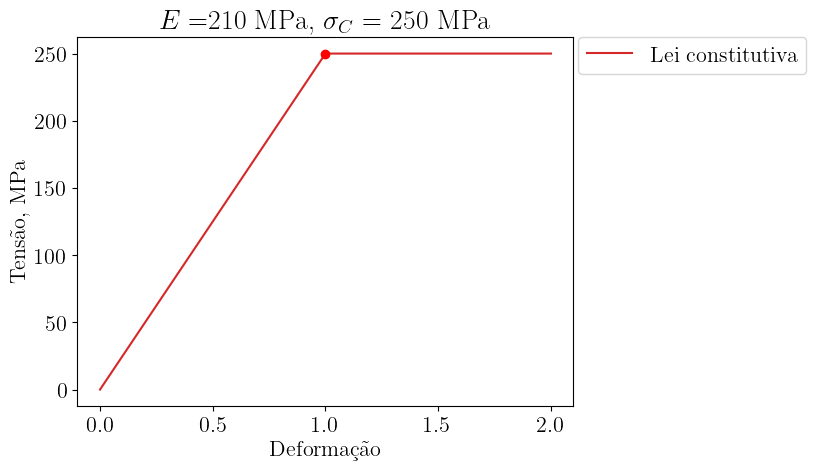

In [41]:
import matplotlib.pyplot as plt
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 16
rc('text', usetex=True)

x = 1
y = SigC

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,x ,2*x], [0,y,y], color='tab:red', label='Lei constitutiva')
ax.plot([x], [y],marker='o',color='r')
plt.title(r'$E=$210 MPa, $\sigma_C$ = 250 MPa', fontsize=20)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xlabel('Deformação')
plt.ylabel('Tensão, MPa')
plt.show()

Esta lei de comportamento do material pode ser convertida num gráfico força-deslocamento para cada barra da estrutura, considerando a geometria da mesma (comprimento e área de secção transversal). (De notar que, inversamente, a curva tensão-deformação se obtem a partir da curva força-deslocamento por normalização da geometria - área de secção transversal e comprimento da barra).

Para esta tranformação o fórmulario necessário é:

\begin{equation*}
F^\mathrm{max} = \sigma_C A \quad\wedge\quad
\delta^\mathrm{Fmax}= \frac{F^\mathrm{max} L }{A E}
\end{equation*}

**Barra $AC$**

AC Fmax = 80.00 kN
AC desl. Fmax = 0.3125 mmm


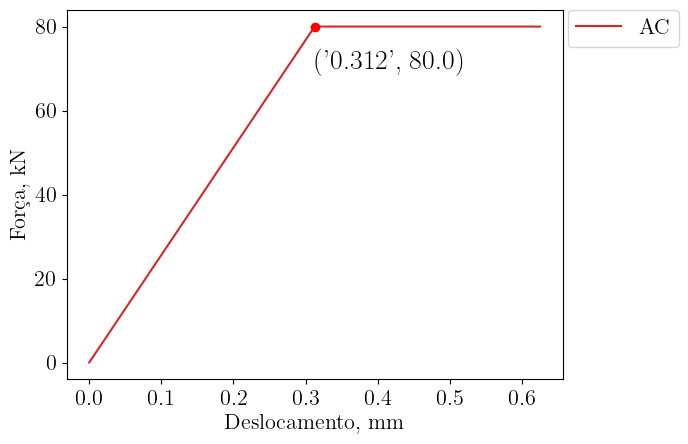

In [42]:
ACFmax = SigC*A1
print(f'AC Fmax = {ACFmax*1e-3:.2f} kN')
ACdesFmax = ACFmax*L1/E/A1
print(f'AC desl. Fmax = {ACdesFmax:.4f} mmm')

def pFig(x,y,cor,leg):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    ax.plot([0,x ,2*x], [0,y,y], color=cor, label=leg)
    ax.plot([x], [y],marker='o',color='r')
    plt.text(x, y-10, ('{:.3f}'.format(x),y), fontsize=20)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
    plt.xlabel('Deslocamento, mm')
    plt.ylabel('Força, kN')
    plt.show()

pFig(ACdesFmax,ACFmax*1e-3,'tab:red','AC')

**Barra $CB$**

Para a barra $CB$ indica-se:

- O ponto de coordenadas para a força máxima da barra ($\delta_{CB}^{F_{CB}^\mathrm{max}},F_{CB}^\mathrm{max}$) - correspondente ao ponto limite de elasticidade e início de cedência;

- O nível de carregamento para a cedência da barra $AC$: ($\delta_{CB}^\mathrm{F_{AC}^\mathrm{max}},F_{AC}^\mathrm{max}$). O que se pode verificar é que a barra $CB$ está no domínio linear elástico quando ocorre
cedência da barra $AC$.


CB Fmax = 137.50 kN
CB desl. Fmax = 0.1875 mm
CB desl. (Fmax de AB) = 0.1091 mm


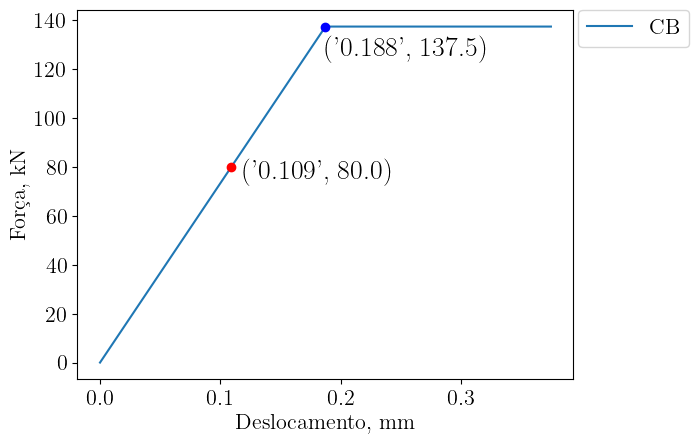

In [43]:
CBFmax = SigC*A2
print(f'CB Fmax = {CBFmax*1e-3:.2f} kN')
CBdesFmax = CBFmax*L2/E/A2
print(f'CB desl. Fmax = {CBdesFmax:.4f} mm')

CBdesFACmax = ACFmax*L2/E/A2
print(f'CB desl. (Fmax de AB) = {CBdesFACmax:.4f} mm')

x1 = CBdesFmax
y1 = CBFmax*1e-3
x2 = CBdesFACmax
y2 = ACFmax*1e-3

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,x1 ,2*x1], [0,y1,y1], color='tab:blue', label='CB')
ax.plot([x1], [y1],marker='o',color='b')
ax.plot([x2], [y2],marker='o',color='r')
plt.text(x1, y1-12, ('{:.3f}'.format(x1),y1), fontsize=20)
plt.text(x2+.01, y2-5, ('{:.3f}'.format(x2),y2), fontsize=20)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xlabel('Deslocamento, mm')
plt.ylabel('Força, kN')
plt.show()

**Barras $AC$ + $CB$**

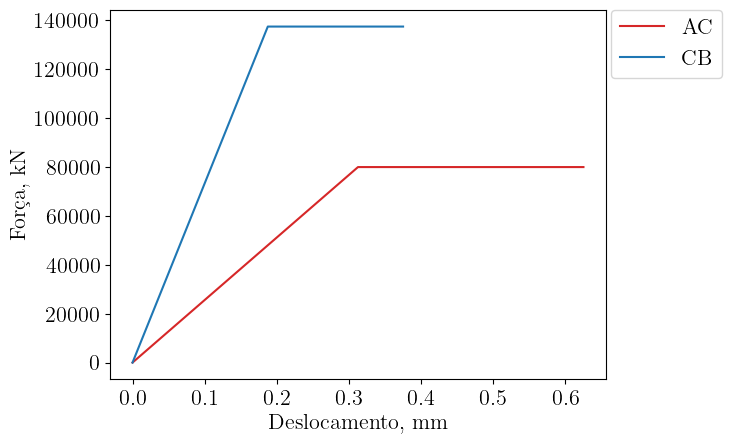

In [44]:
xA, yA = ACdesFmax, ACFmax
xB, yB = CBdesFmax, CBFmax

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,xA ,2*xA], [0,yA,yA], color='tab:red', label='AC')
ax.plot([0,xB ,2*xB], [0,yB,yB], color='tab:blue', label='CB')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.xlabel('Deslocamento, mm')
plt.ylabel('Força, kN')
plt.show()


Deslocamento total à força máxima (limite de elasticidade) para a barra AC:
Desl. total = 0.4216 mm


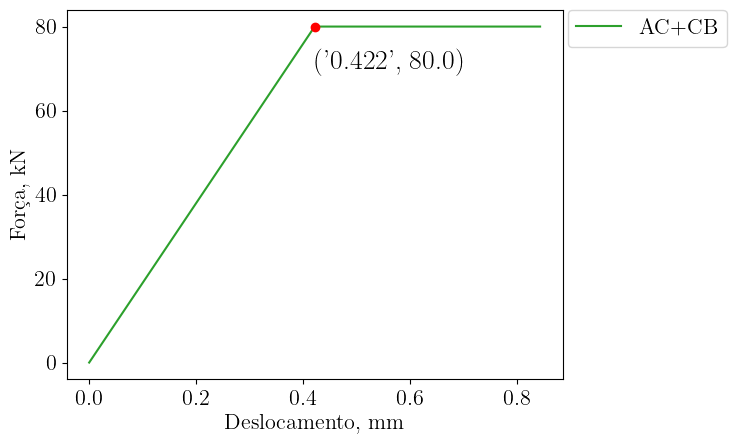

In [45]:
deslTotFmax = ACdesFmax+CBdesFACmax
print('Deslocamento total à força máxima (limite de elasticidade) para a barra AC:')
print(f'Desl. total = {deslTotFmax:.4f} mm')

pFig(deslTotFmax,ACFmax*1e-3,'tab:green','AC+CB')

**Método da sobreposição**

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au09/Au09_P007_i2.jpg"
width="700">

A barra está confinada entre os dois encastramentos. Pelo aumento da temperatura existirá uma expansão da barra. Essa variação de comprimento irá gerar uma força axial de reação na ligação ao exterior da barra. Essas forças axiais são de igual intensidade mas de sentidos opostos:

\begin{equation*}
\begin{aligned}
(+)\rightarrow~&:~\sum F_x=0
~\Leftrightarrow~
F_{A} - F_{B} = 0
~\Leftrightarrow~
F_{A} = F_{B} = F\\
\end{aligned}
\end{equation*}

O problema em questão é estaticamente indeterminado. A sua solução pode passar pelo método da sobreposição. Na aplicação deste método, uma das reações é removida e o seu efeito considerado como uma pseudo-força externa aplicada à estrutura de base, dita de isostática equivalente.

Assim sendo, remova-se, por exemplo, o encastramento direito. Pela variação (aumento) da temperatura ($\Delta T$) ocorrerá uma extensão (alongamento) do conjunto de barras $ACB$, $\delta^T$. Sobrepondo-se a esse efeito, existe a compressão da barra $ACB$ pela aplicação da força pseudo-externa, $F$, responsável por uma variação de comprimento $\delta^F$.

##### Equação de compatibilidade

A equação de compatibilidade de deslocamento na secção do encastramento direito permite escrever:

\begin{equation*}
\begin{aligned}
\delta^T - \delta^F = 0
~\Leftrightarrow~
\delta^T = \delta^F
\end{aligned}
\end{equation*}

em que $\delta^T$ representa um alongaento por efeito térmico (aumento da temperatura), e $\delta^F$ representa uma contração da barra por efeito de compressão da força redundante (exercída pelo encastramento).

As barras em série $AC$ e $CB$ permitem escrever:

\begin{equation*}
\begin{aligned}
\delta^T &= \delta_{AC}^T + \delta_{CB}^T = \alpha \Delta T (L_{AC} + L_{CB})\\
\delta^F &= \delta_{AC}^F + \delta_{CB}^F = \frac{F}{E}\left(\frac{L_{AC}}{A_{AC}} + \frac{L_{CB}}{A_{CB}}\right)
\end{aligned}
\end{equation*}

Desenvolvendo algebricamente (${AC}\equiv 1, {CB}\equiv 2$),

\begin{equation*}
\begin{aligned}
\delta^T = \delta^F
&~\Leftrightarrow~
\delta_1^T + \delta_2^T = \delta_1^F+\delta_2^F \\
&~\Leftrightarrow~
\alpha \Delta T (L_1+L_2) = \frac{F}{E}\left(\frac{L_1}{A_1} + \frac{L_2}{A_2}\right) \\
&~\Leftrightarrow~
F = \frac{\alpha\Delta T (L_1+L_2)E}{
\left(\displaystyle\frac{L_1}{A_1} + \displaystyle\frac{L_2}{A_2}\right)}
\quad\textrm{(força de compressão)}
\end{aligned}
\end{equation*}

In [46]:
from numpy import abs

num = alpha*DT*(L1+L2)*E
den = L1/A1 + L2/A2
F = num/den
print(f'F = {F:.2f} N | {abs(F*1e-3):.1f} kN (Compressão, C)')


F = 159851.64 N | 159.9 kN (Compressão, C)


Por outro lado, é possível conhecer, pelos dados enunciados, o valor da força máxima no limite de elasticidade, correspondente a uma tensão de cedência do material ($\sigma_C = 250$ MPa).

In [47]:
F1max = SigC*A1
print(f'F1max = {F1max:.2f} N | {abs(F1max*1e-3):.1f} kN [Regime plástico]')
F2max = SigC*A2
print(f'F2max = {F2max:.2f} N | {abs(F2max*1e-3):.1f} kN [Regime elástico]')

F1max = 80000.00 N | 80.0 kN [Regime plástico]
F2max = 137500.00 N | 137.5 kN [Regime elástico]


De notar que, a força axial aplicada (159.9  kN ; compressão) é superior à força de cedência das barras. Contudo, a barra menos rígida $AC$ irá entrar em cedência em primeiro lugar, pilotando o comportamento da estrutura a partir de uma força induzida igual à sua força de cedência (80.0  kN) - assim sendo,  ocorrerá plasticidade da barra $AC$ a partir desse instante.

O deslocamento da barra $AC$ será resultado do contributo de origem térmica e de origem mecânica. Os seus valores relativos podem ser determinados por:

In [48]:
dACTerm = alpha*DT*L1
print(f'del. AC Termica = {dACTerm:.3f} mm')

dACMec  = -F*L1/E/A1
print(f'desl. AC Mecanica = {dACMec:.3f} mm')

del. AC Termica = 0.526 mm
desl. AC Mecanica = -0.624 mm


De notar que o deslocamento (contração) devido à força aplicada é superior ao deslocamento (expansão) devido à variação térmica. Pelo que na configuração final a barra $AC$ irá sofrer uma deformação plástica (permanente) de contração.

Analisando o ponto de inflexão da lei constitutiva força-deslocamento para o material elasto-plástico:

\begin{equation*}
F_\mathrm{max} = F_{AC} = F_{CB}  = 80.0  ~\textrm{kN}
\end{equation*}

Pelo que o diagrama de esforço axial resulta:

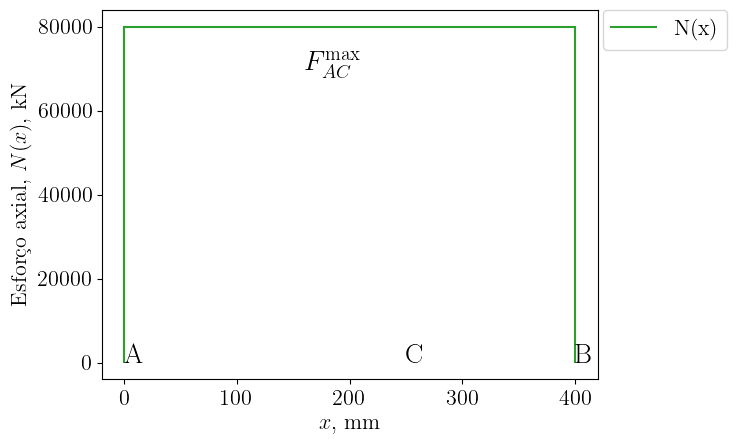

In [49]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,L1, L1+L2], [F1max,F1max,F1max], color='tab:green', label='N(x)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.vlines(0, ymin=0, ymax=F1max,color='tab:green')
plt.vlines(L1+L2, ymin=0, ymax=F1max,color='tab:green')
plt.text((L1+L2)/2.5, F1max*.87, r'$F_{AC}^\mathrm{max}$', fontsize=20)
plt.text(0, 1, r'A', fontsize=20)
plt.text(L1, 1, r'C', fontsize=20)
plt.text(L1+L2, 1, r'B', fontsize=20)
plt.xlabel(r'$x$, mm')
plt.ylabel('Esforço axial, $N(x)$, kN')
plt.show()

Pelo que as tensões normais nas barras serão:

\begin{equation*}
\begin{aligned}
\sigma_{AC} &\equiv \sigma_{C} = 250~\textrm{MPa} \\
\sigma_{CB} & = \frac{F_\mathrm{max}}{A_{CB}} \\
\end{aligned}
\end{equation*}

In [50]:
Fmax = F1max

sigAC = SigC
print(f'sigAC = {sigAC:.2f} MPa')

sigCB = Fmax/A2
print(f'sigCB = {sigCB:.2f} MPa')

sigAC = 250.00 MPa
sigCB = 145.45 MPa


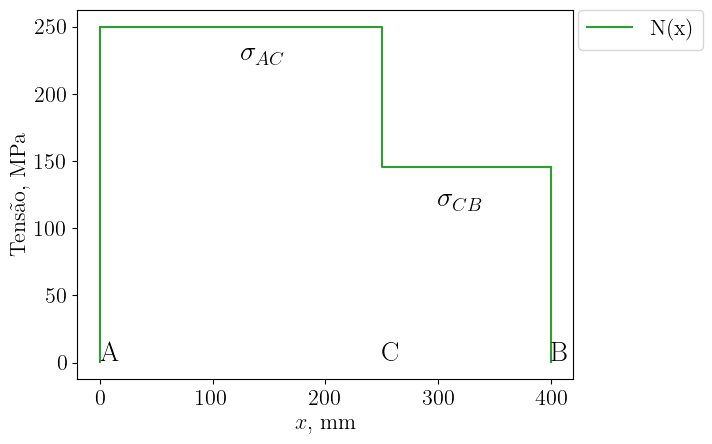

In [51]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot([0,L1,L1, L1+L2], [sigAC,sigAC,sigCB,sigCB], color='tab:green', label='N(x)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.vlines(0, ymin=0, ymax=sigAC,color='tab:green')
plt.vlines(L1+L2, ymin=0, ymax=sigCB,color='tab:green')
plt.text(L1/2, sigAC*.9, r'$\sigma_{AC}$', fontsize=20)
plt.text(L1+L2/3, sigCB*.8, r'$\sigma_{CB}$', fontsize=20)
plt.text(0, 1, r'A', fontsize=20)
plt.text(L1, 1, r'C', fontsize=20)
plt.text(L1+L2, 1, r'B', fontsize=20)
plt.xlabel(r'$x$, mm')
plt.ylabel('Tensão, MPa')
plt.show()

#### b) Diga o que entende por comportamento elastoplástico? Explique também o que entende por deformações residuais e por tensões residuais?. <a id="B"></a>

**Deformação residual:**

Quando a força aplicada ultrapassa o nível de tensão de cedência ocorre plasticidade. A existência de deformação plástica durante a fase de aquecimento implica a ocorrência de deformações residuais durante a fase de arrefecimento, ou seja, a deformação não será zero depois do arrefecimento.

**Tensões residual:**

Tensões residuais podem ocorrer, por exemplo, quando um material é submetido a ciclos térmicos de aquecimento e arrefecimento. Se a expansão ou contração do material for impedida ou obstruída, podem ocorrer internamente tensões residuais no material. As tensões residuais são forças internas de auto balanço e não são provodadas por forças externas diretamente aplicadas. As tensões residuais podem ocorrer por vários mecanismos incluindo: (i) deformações plástica não uniformes em partes da estrutura, (ii) gradientes de temperatura (ciclos térmicos); (iii) alterações estruturais (transformação de fases).


#### c) Obtenha as tensões em cada troço depois da barra arrefecer até à temperatura ambiente. <a id="C"></a>

**Método da sobreposição + Equação de compatibilidade**

Da análise anterior foi possível concluir que quando a temperatura aumenta até $T=200$ $^\circ$C, ocorre deformação plástica da barra $AC$. Logo, para esse nível de temperatura a equação de compatibilidade de deslocamentos escreve-se:

\begin{equation*}
\delta^T = \delta^F
~\Leftrightarrow~
\delta_{AC}^T + \delta_{CB}^T =
\delta_{AC}^t + \delta_{CB}^e = (\delta_{AC}^e + \delta_{AC}^p) + \delta_{CB}^e
\end{equation*}

A esta temperatura a força aplicada à barra $AC$ excede o seu limite de elasticidade, pelo que: $\delta_{AC}^t =\delta_{AC}^e + \delta_{AC}^p$. A equação anterior pode ser resolvida para a deformação plástica induzida na barra $AC$:

\begin{equation*}
\begin{aligned}
\delta_{AC}^p &= \delta_{AC}^T + \delta_{CB}^T - (\delta_{AC}^e + \delta_{CB}^e)\\
\delta_{AC}^p &= \alpha\Delta T (L_{AC} + L_{CB}) - \frac{F_{AC}^\mathrm{max}}{E}\left( \frac{L_{AC}}{A_{AC}} + \frac{L_{CB}}{A_{CB}} \right)\\
\end{aligned}
\end{equation*}

**Diagrama de corpo livre + Equação de compatibilidade**

Analisando a deformação individual de cada barra e vendo a compatibilidade de deslocamentos:

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au09/Au09_P007_i3.jpg"
width="700">

Da análise da deformada pelo diagrama de corpo livre individual de cada barra, conclui-se pela equação de compatibilidade do deslocamento na secção $C$:

\begin{equation*}
-\delta_{AC}^p-\delta_{AC}^e+\delta_{AC}^T
=-\delta_{CB}^T+\delta_{CB}^e
\end{equation*}

A barra $AC$ terá um alongamento pelo aumento da temperatura de $\delta_{AC}^T$. Por outro lado, devido ao esforço de compressão introduzido pelo encastramento (ligação ao exterior), ocorre uma variação de comprimento total: $\delta_{AC}^t = \delta_{AC}^p-\delta_{AC}^e$. A barra $CB$ irá expandir pelo aumento da temperatura $\delta_{CB}^T$ e encurtar pela força axial compressiva (regime elástico): $\delta_{CB}^e$. Assim,

\begin{equation*}
\begin{aligned}
\delta_{AC}^p
&=\delta_{CB}^T+\delta_{AC}^T - (\delta_{CB}^e + \delta_{AC}^e)\\
\delta_{AC}^p &= \alpha\Delta T (L_{AC} + L_{CB}) - \frac{F_{AC}^\mathrm{max}}{E}\left( \frac{L_{AC}}{A_{AC}} +
\frac{L_{CB}}{A_{CB}} \right)\\
\end{aligned}
\end{equation*}

In [52]:
frac1 = alpha*DT*(L1+L2)
frac2 = Fmax/E*(L1/A1 + L2/A2)
delACplast = frac1 - frac2
print('desl. AC (plastico) = ','{:.4f}'.format(delACplast),' mm')

desl. AC (plastico) =  0.4208  mm


Pelo que, após arrefecimento da barra total ($AC + CB$) ocorrerá uma deformação permanente. Existirá uma força ou tensão residual responsável por essa deformação que pode ser obtida por:

\begin{equation*}
\begin{aligned}
\delta_{AC}^p \equiv \delta_{\mathrm{res}}^F &=
\frac{F_{\mathrm{res}}}{E}\left(\frac{L_{AC}}{A_{AC}} + \frac{L_{CB}}{A_{CB}}\right) \\
F_{\mathrm{res}} &= \frac{\delta_{\mathrm{res}}^F E}
{\left(\displaystyle\frac{L_{AC}}{A_{AC}} + \displaystyle\frac{L_{CB}}{A_{CB}}\right)}
\end{aligned}
\end{equation*}

De notar que a barra $ACB$ está rigidamente fixa aos encastramentos. A força de compressão redundante obrigaria a uma compressão da barra, contudo isso não pode acontecer devido à ligação rígida ao exterior. Desta forma, a barra $ACB$ estará submetida a uma força residual de tração que a mantem na sua posição original da configuração inicial.

In [53]:
Fres = delACplast*E/(L1/A1 + L2/A2)
print(f'Forca residual (pelo desl. plastico) = {Fres:.4f} N | (tração, T)')

Forca residual (pelo desl. plastico) = 79851.6442 N | (tração, T)


Assim sendo existirá nas barras de secção variável $AC$ e $CB$ as seguintes tensões residuais (de tração):

In [56]:
SACres = Fres/A1
print(f'Tensão residual barra AC (pelo desl. plastico) = {SACres:.2f} MPa | (tração, T)')
SCBres = Fres/A2
print(f'Tensão residual barra CB (pelo desl. plastico) = {SCBres:.2f} MPa | (tração, T)')

Tensão residual barra AC (pelo desl. plastico) = 249.54 MPa | (tração, T)
Tensão residual barra CB (pelo desl. plastico) = 145.18 MPa | (tração, T)


#### d) Calcule a distância a que a secção $C$ distará da secção $A$ depois da barra arrefecer. <a id="D"></a>

Durante o aquecimento e arrefecimento, a barra $CB$ comporta-se no regime do domínio linear elástico. Contudo, a barra $AC$ entratá no domínio plástico. Por isso, devido ao efeito da deformação/tensão residual as barras não voltaram à sua configuração inicial. A barra $CB$ recuperará a sua deformação elástica, mas estará submetida a um estado de tensão de auto-equilíbrio com a barra $AC$, que sofre uma deformação plástica (residual). Essa força residual  exerce uma tração sobre a barra $CB$, responsável pelo deslocamento da secção $C$. Pelo que no final do arrefecimento:

\begin{equation*}
\overline{AC}\,{'} = \overline{AC} - \delta_C^\textrm{res}
= \overline{AC} - \frac{F_{\textrm{res}}L_{CB}}{A_{CB}E}
\end{equation*}

In [57]:
deslCBr = Fres*L2/A2/E
print(f'desl. CB residual = {deslCBr:.3f} mm')

ACdef = L1 - deslCBr
print(f'comprimento inicial AC (ref) = {L1:.1f} mm')
print(f'comprimento atual AC (def) = {ACdef:.3f} mm')

desl. CB residual = 0.109 mm
comprimento inicial AC (ref) = 250.0 mm
comprimento atual AC (def) = 249.891 mm


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au09/Au09_P007_i4.jpg"
width="600">


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
